### CREDIT CARD FRAUD DETECTION

Load all necessary libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve,average_precision_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

import joblib

Import & Inspect Dataset

In [25]:
df = pd.read_csv("creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check shape of Dataset

In [26]:
df.shape

(284807, 31)

Check proportion of both occurence

In [27]:
fraud_rate = df["Class"].value_counts(normalize=True)*100
fraud_rate

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Plot distribution of both occurrence

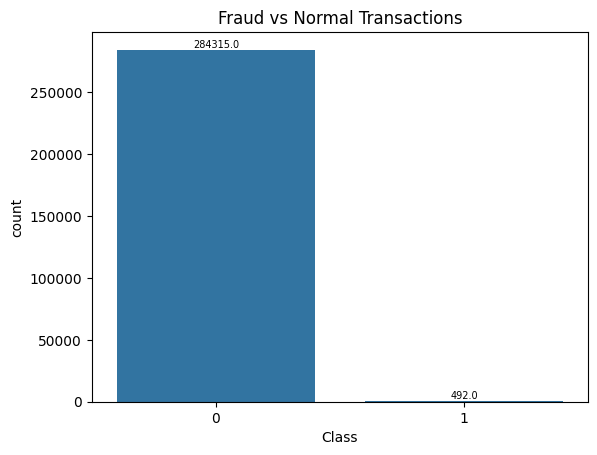

In [28]:
ax = sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=7)

plt.show()

Check for outliers with Boxplot

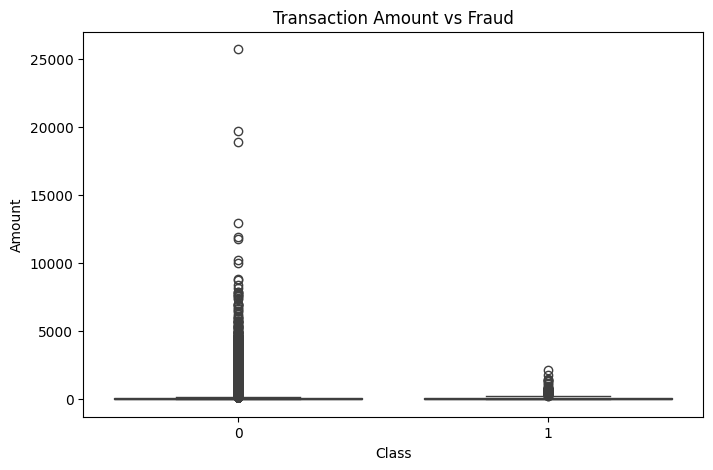

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

Create 'Hour' column with 'Time' column

In [30]:
df["Hour"] = (df["Time"]//3600) % 24
df.tail(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0,23.0


Check the hourly distribution of classes

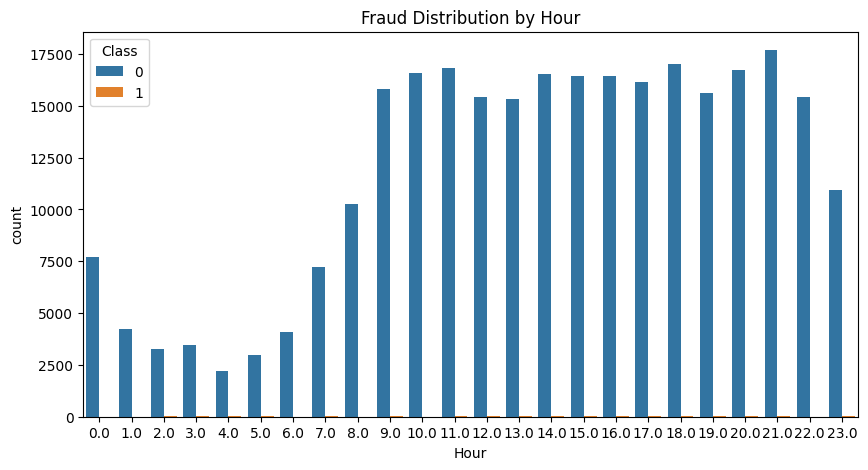

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(x="Hour", hue="Class", data=df)
plt.title("Fraud Distribution by Hour")
plt.show()

Split Dataset into Features & Target

In [32]:
x = df.drop("Class", axis = 1)
y = df["Class"]

Split Dataset into Training & Testing sets

In [33]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print(x_test.shape,x_train.shape)

(56962, 31) (227845, 31)


Balance Imblanced Dataset

In [34]:
smote = SMOTE(sampling_strategy=0.2,random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train,y_train)

print(f"Before SMOTE:{sum(y_train==1)} fraud cases")
print(f"After SMOTE:{sum(y_train_res==1)} fraud cases")

Before SMOTE:394 fraud cases
After SMOTE:45490 fraud cases


Standardize Amount Column

In [35]:
feature_names = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_res[feature_names])
x_test_scaled = scaler.transform(x_test[feature_names])

Note: we do NOT “fit” on the test set, because we don’t want to leak information from the test set into training.

Train Logistic Regression Model

In [36]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

lr.fit(x_train_scaled, y_train_res)

y_pred_proba = lr.predict_proba(x_test_scaled)[:,1]

ap_lr = average_precision_score(y_test, y_pred_proba)

print(f"Logistic Regression AUPRC: {ap_lr:.4f}")

Logistic Regression AUPRC: 0.7365


Train Random Forest Classifier Model

In [37]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(x_train_res,y_train_res)

y_pred_proba_rf = rf.predict_proba(x_test)[:,1]
ap_rf = average_precision_score(y_test,y_pred_proba_rf)
print(f"Random Forest Classifier AUPRC: {ap_rf:.4f}")


Random Forest Classifier AUPRC: 0.8156


Train XGBoost Model

In [38]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(x_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(x_test)[:,1]

ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"XGBoost AUPRC: {ap_xgb:.4f}")

c:\Users\reginald.erzoah\OneDrive - Koa Impact\Desktop\Resources\Python Practice\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:05:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.8854


Model Threshold Optimization

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)

target_recall = 0.80
idx = np.argmax(recall >= target_recall)

threshold = thresholds[idx]

print(f"Threshold for 80% recall: {threshold:.12f}")

Threshold for 80% recall: 0.000000000808


Compute SHAP values 

In [40]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_test)

SHAP Summary Plot (Global Feature Importance)

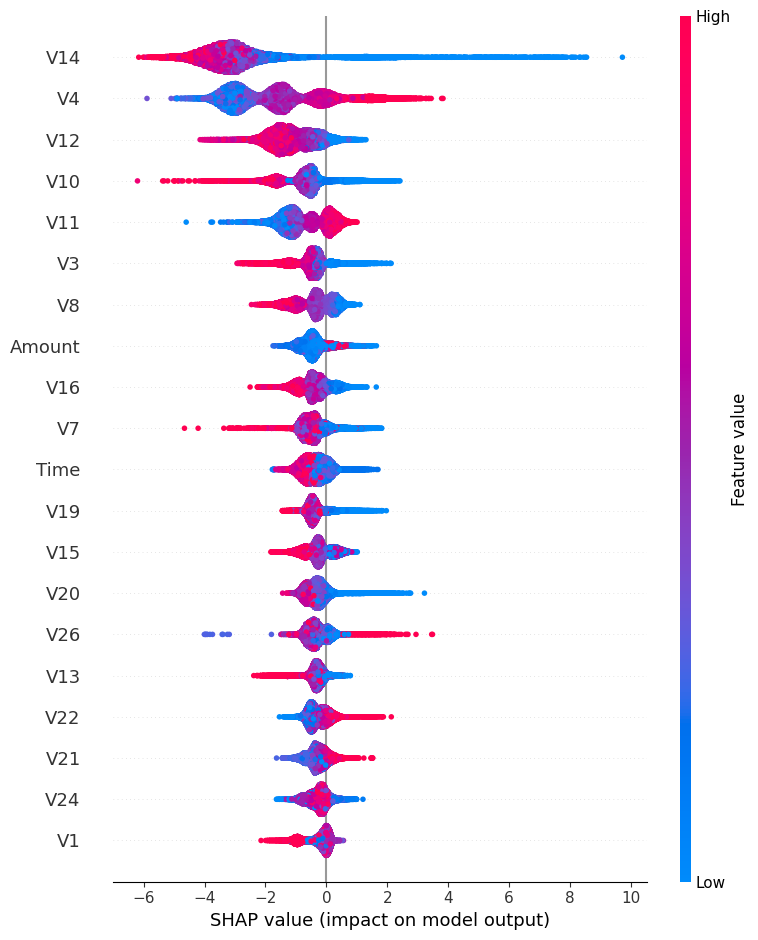

In [41]:
shap.summary_plot(shap_values, x_test)

SHAP Feature Importance (Bar Plot)

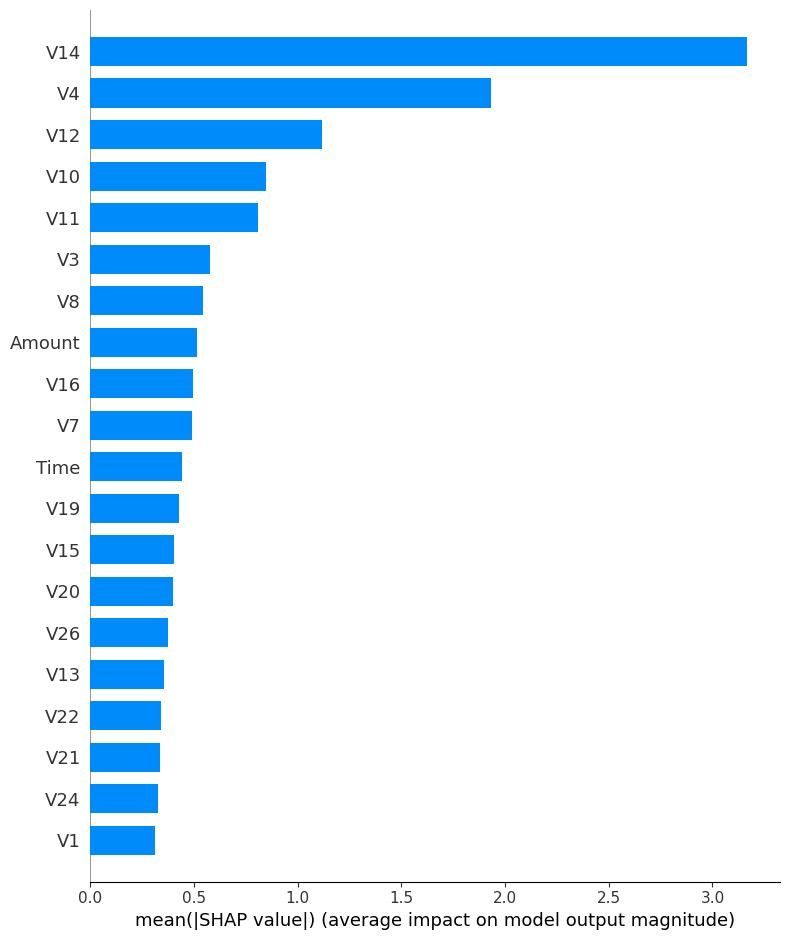

In [42]:
shap.summary_plot(shap_values, x_test, plot_type="bar")

SHAP Dependence Plot (Feature Impact Analysis)

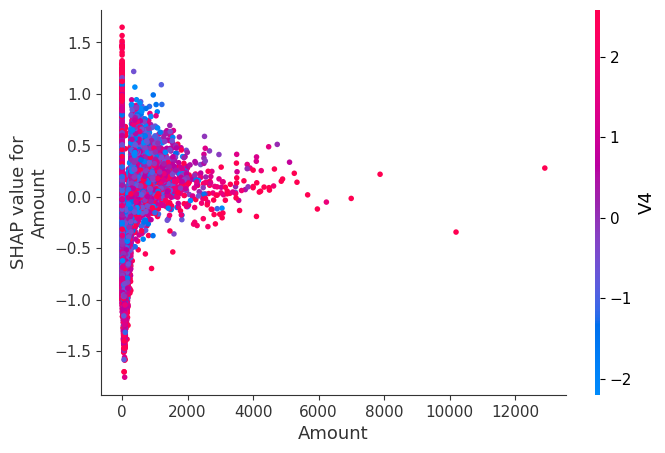

In [43]:
shap.dependence_plot("Amount", shap_values, x_test)

Model Performance Summary

In [44]:
results = {
    "Logistic Regression": ap_lr,
    "Random Forest": ap_rf,
    "XGBoost": ap_xgb
}

print("Model Performance Summary (AUPRC)\n")

for model, score in results.items():
    print(f"{model}: {score:.4f}")

best_model = max(results, key=results.get)
best_score = results[best_model]

print("\nBest Model Based on AUPRC:")
print(f"{best_model} with a score of {best_score:.4f}")

Model Performance Summary (AUPRC)

Logistic Regression: 0.7365
Random Forest: 0.8156
XGBoost: 0.8854

Best Model Based on AUPRC:
XGBoost with a score of 0.8854


Conclusion 

In [45]:
print("\nConclusion:")
print(
    f"Among the evaluated models, {best_model} achieved the highest AUPRC score "
    f"of {best_score:.4f}. Since credit card fraud detection is a highly "
    "imbalanced classification problem, AUPRC is an appropriate evaluation "
    "metric. Therefore, this model provides the best balance between precision "
    "and recall and is selected as the final model for fraud detection."
)


Conclusion:
Among the evaluated models, XGBoost achieved the highest AUPRC score of 0.8854. Since credit card fraud detection is a highly imbalanced classification problem, AUPRC is an appropriate evaluation metric. Therefore, this model provides the best balance between precision and recall and is selected as the final model for fraud detection.


Save all deployment objects (models, scaler & SHAP explainer)

In [46]:
xgb_model.save_model("xgb_model.json")

deployment_objects = {
    "logreg": lr,
    "rf": rf,
    "scaler": scaler,
    "feature_names": feature_names
}

joblib.dump(deployment_objects, "fraud_detection_deployment_objects.pkl")

['fraud_detection_deployment_objects.pkl']